In [2]:
import numpy as np
import matplotlib.pyplot as plt
eps = np.finfo(float).eps

### Table of Contents
Proofs
- [Gradient Descent Convergence Theorem](#Proof-of-the-Gradient-Descent-Convergence-Theorem)
- [Linear Convergence](#Proof-of-Linear-Convergence)
- [Exact Line Search](#Exact-Line-Search-Deriviations)

Implementation
- [Gradient Descent, Line Search, and Nesterov Comparisons](#gradient-descent-line-search-and-nesterov-comparisons)
- [Gradient Descent Path Visualization with Rosenbrock](#gradient-descent-path-visualization-with-rosenbrock)
- [Gradient Descent applied to Rastrigin](#gradient-descent-applied-to-rastrigin)
- [Stochastic Gradient Descent](#stochastic-gradient-descent)

Failure Points
- [Multiple Minima](#functions-with-multiple-minima)
- [Saddle Points](#Gradient-Descent-in-Higher-Dimensions:-Saddle-Points)
- [Step Sizes](#poor-step-sizes)
- [Perturbation](#Perturbation)

Sources
- [Sources](#Sources)

# Proof of the Gradient Descent Convergence Theorem

For a smooth convex function $f: \mathbb{R}^n \rightarrow \mathbb{R}$, prove the $\textbf{gradient descent convergence theorem}$: with step size $\eta = \frac{1}{L}$ where $L$ is the Lipschitz constant of $\nabla f$, gradient descent satisfies $f(x_k) - f(x_*) \leq \frac{L\lVert x_0 - x^* \rVert^2}{2k}$.

Let us begin by letting $f: \mathbb{R}^n \rightarrow \mathbb{R}$ be a smooth convex function. Next let us define the Gradient Descent Formula as $$x_{k + 1} = x_k - \eta \nabla f(x_k)$$ where $x_k$ is the current position, $\eta$ is the step size, which shall be $\frac{1}{L}$, and $\nabla f(x_k)$ is the gradient of $f$ at $x_k$. Lastly, $L$ is the Lipschitz constant of $\nabla f$, which is a constant such that $\lVert \nabla f(x) - \nabla f(y) \rVert \leq L\lVert x - y \rVert$ $\forall x, y \in f$

We can apply the Descent Lemma first, given that we know $f: \mathbb{R}^n \rightarrow \mathbb{R}$ is a smooth function with a step size $\eta \in [0, \frac{1}{L}]$ and $x_{k + 1} = x_k - \eta \nabla f(x_k)$
$$f(x_{k + 1}) \leq f(x_k) - \frac{\eta}{2} \lVert \nabla f(x_k) \rVert^{2}_{2}$$
<center> We can lastly substitute $\eta = \frac{1}{L}$ to obtain
$$f(x_{k + 1}) \leq f(x_k) - \frac{1}{2L} \lVert \nabla f(x_k) \rVert^{2}_{2}$$

Next we can apply a behavior of convex functions to bound $f(x_{k + 1})$ in terms of the optimal value $f(x_*)$. As $f$ is convex, we can find that $f(x_k) \leq f(x_*) + \nabla f(x_k)^T(x_k - x_*)$, plugging this into the formula we found, we obtain
$$f(x_{k + 1}) \leq f(x_*) + \nabla f(x_k)^T(x_k - x_*) - \frac{1}{2L} \lVert \nabla f(x_k) \rVert^{2}_{2}$$
$$f(x_{k + 1}) - f(x_*) \leq \nabla f(x_k)^T(x_k - x_*) - \frac{1}{2L} \lVert \nabla f(x_k) \rVert^{2}_{2}$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\frac{2}{L}\nabla f(x_k)^T(x_k - x_*) - \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2}_{2})$$

Notice how $\lVert x_k - \frac{1}{L}\nabla f(x_k) + x_* \rVert_{2}^{2}$ expands out to $\lVert x_k - x_* \rVert^{2}_{2} - \frac{2}{L}\nabla f(x_k)^T(x_k - x_*) + \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2}_{2}$ when completing the square.

$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(-1(\frac{-2}{L}\nabla f(x_k)^T(x_k - x_*) + \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2}_{2} + \lVert x_k - x_* \rVert^{2}_{2}) + \lVert x_k - x_* \rVert^{2}_{2})$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\lVert x_k - x_* \rVert^{2}_{2} - \lVert x_k - \frac{1}{L}\nabla f(x_k) + x_* \rVert_{2}^{2})$$

<center> Recall the Gradient Descent Formula $x_{k + 1} = x_k - \frac{1}{L} \nabla f(x_k)$. </center>

$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\lVert x_k - x_* \rVert^{2}_{2} - \lVert x_{k + 1} + x_* \rVert_{2}^{2})$$

This inequality holds true over all iterations of $x_*$, as such summation over iterations we obtain: </center>
$$\sum_{i = 1}^{k} f(x_i) - f(x_*) \leq \sum_{i = 1}^{k} \frac{L}{2}(\lVert x_{i - 1} - x_* \rVert^{2}_{2} - \lVert x_i - x_* \rVert_{2}^{2})$$
Notably this is a telescoping sum! As a result:
$$\sum_{i = 1}^{k} \frac{L}{2}(\lVert x_{i - 1} - x_* \rVert^{2}_{2} - \lVert x_i + x_* \rVert_{2}^{2}) = \frac{L}{2}(\lVert x_0 - x_* \rVert^{2}_{2} - \lVert x_{k} - x_* \rVert_{2}^{2}) 
= \frac{L}{2}(\lVert x_0 - x_* \rVert^{2})$$

Lastly, as we know that $f$ is decreasing every iteration, we can conclude:
$$f(x_k) - f(x_*) \leq \frac{1}{k} \sum_{i = 1}^{k} f(x_i) - f(x_*) \leq \frac{L}{2k}(\lVert x_0 - x_* \rVert^{2})$$
Hence: $f(x_k) - f(x_*) \leq \frac{L\lVert x_0 - x_* \rVert^{2}}{2k}$   $\square$

In [3]:
def gradientDescent(start=0, learningRate=0.1, iterations=100, tol=1e-6):
    x = start
    path = [x]
    for i in range(iterations):
        step = learningRate * df(x)
        x -= step
        path.append(x)
        if abs(step) < tol:
            break
    return x, path

In [4]:
# x^2 is a convex function.
def f(x):
    return x**2 + 4*x + 4

# The function is smooth and differentiable.
def df(x):
    return 2*x + 4

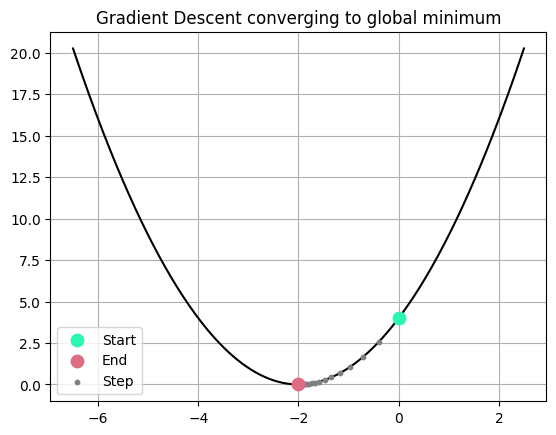

In [5]:
x, path = gradientDescent()

fig, ax = plt.subplots()
xs = np.linspace(-6.5, 2.5, 300)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to global minimum")

plt.show()


# Proof of Linear Convergence

For strongly convex $f$ (with parameter $\mu > 0$), prove linear convergence: $f(x_k) − f^∗ \leq (1 - \frac{\mu}{L})^k (f(x_0) − f^∗)$. Define the condition number $\kappa = \frac{L}{\mu}$ and show that convergence
slows as $\kappa → \infty$.

Unlike in the previous Proof, we now have a strongly convex function, this imposes a new restriction as defined as $f(y) \geq f(x) + [\nabla f(x), y - x] + \frac{1}{2}\mu \lVert x - y \rVert^2$ where $\mu > 0$. This can be rewritten in accordance with the above proof as:
$$f(x_k) \leq f(x_*) + \nabla f(x_k)^T(x_k - x_*) - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$

Let's plug this into our update rule: $f(x_{k + 1}) \leq f(x_k) - \frac{1}{2L} \lVert \nabla f(x_k) \rVert^{2}_{2}$
$$f(x_{k + 1}) - f(x_*) \leq \nabla f(x_k)^T(x_k - x_*) - \frac{1}{2L} \lVert \nabla f(x_k) \rVert^{2} - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\frac{2}{L} \nabla f(x_k)^T(x_k - x_*) - \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2}) - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$

Just as in the Gradient Descent Convergence Proof, we can complete the square as $\lVert x_k - \frac{1}{L}\nabla f(x_k) - x_* \rVert^{2} = \lVert x_k - x_* \rVert^{2} - \frac{2}{L}\nabla f(x_k)^T(x_k - x_*) + \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2}$

$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(-1(\frac{-2}{L}\nabla f(x_k)^T(x_k - x_*) + \frac{1}{L^2} \lVert \nabla f(x_k) \rVert^{2} + \lVert x_k - x_* \rVert^{2}) + \lVert x_k - x_* \rVert^{2}) - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\lVert x_k - x_* \rVert^{2} - \lVert x_k - \frac{1}{L}\nabla f(x_k) + x_* \rVert^{2}) - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$

 Recall the Gradient Descent Formula $x_{k + 1} = x_k - \frac{1}{L} \nabla f(x_k)$.

$$f(x_{k + 1}) - f(x_*) \leq \frac{L}{2}(\lVert x_k - x_* \rVert^{2} - \lVert x_{k + 1} - x_* \rVert^{2}) - \frac{1}{2}\mu \lVert x_k - x_* \rVert^2$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{1}{2}(L - \mu)(\lVert x_k - x_* \rVert^{2}) - \frac{1}{2}L(\lVert x_{k + 1} - x_* \rVert^{2})$$

Let's reexamine the definition for a strongly convex function and rearrange for $\lVert x_k - x_* \rVert^2$. We'll begin with the strongly convex function; however we will substitute $x = x_*$ and $y = x_k$ this time. Lastly, as $x_*$ is the global minimum, we know that $\nabla f(x_*) = 0$
$$f(x_*) \leq f(x_k) + \nabla f(x_*)^T(x_* - x_k) - \frac{1}{2}\mu \lVert x_* - x_k \rVert^2$$
$$f(x_*) \leq f(x_k) + 0(x_* - x_k) - \frac{1}{2}\mu \lVert x_* - x_k \rVert^2$$
$$\frac{1}{2}\mu \lVert x_* - x_k \rVert^2 \leq f(x_k) - f(x_*)$$
$$\lVert x_* - x_k \rVert^2 \leq \frac{2}{\mu} (f(x_k) - f(x_*))$$
Let's plug this back into our previous equation
$$f(x_{k + 1}) - f(x_*) \leq \frac{1}{2}(L - \mu)(\frac{2}{\mu} (f(x_k) - f(x_*))) - \frac{1}{2}L(\lVert x_{k + 1} - x_* \rVert^{2})$$
$$f(x_{k + 1}) - f(x_*) \leq \frac{1}{\mu}(L - \mu)(f(x_k) - f(x_*)) - \frac{1}{2}L(\lVert x_{k + 1} - x_* \rVert^{2})$$
$$f(x_{k + 1}) - f(x_*) \leq (1 - \frac{L}{\mu})(f(x_k) - f(x_*)) - \frac{1}{2}L(\lVert x_{k + 1} - x_* \rVert^{2})$$

We know that $\frac{1}{2}L(\lVert x_{k + 1} - x_* \rVert^{2})$ is a positive number, so it can be safely dropped without loosening our bound, obtaining:
$$f(x_{k + 1}) - f(x_*) \leq (1 - \frac{L}{\mu})(f(x_k) - f(x_*))$$

Solving for $f(x_{k+1})$ we obtain $f(x_{k + 1}) \leq (1 - \frac{L}{\mu})(f(x_k) - f(x_*)) + f(x_*)$, as a result, if $k = 0$, we obtain:
$$f(x_1) \leq (1 - \frac{L}{\mu})(f(x_0) - f(x_*)) + f(x_*)$$
Let's find, $k = 2$:
$$f(x_2) \leq (1 - \frac{L}{\mu})((1 - \frac{L}{\mu})(f(x_0) - f(x_*)) + f(x_*) - f(x_*)) + f(x_*)$$
$$f(x_2) \leq (1 - \frac{L}{\mu})^2(f(x_0) - f(x_*)) + f(x_*)$$
Finally, let's expand to $k = k$:
$$f(x_k) \leq (1 - \frac{L}{\mu})^{k - 1}((1 - \frac{L}{\mu})(f(x_0) - f(x_*)) + f(x_*) - f(x_*) + f(x_*) - ... + f(x_*) - f(x_*)) + f(x_*)$$
$$f(x_k) \leq (1 - \frac{L}{\mu})^k(f(x_0) - f(x_*)) + f(x_*)$$
$f(x_k) - f(x_*) \leq (1 - \frac{L}{\mu})^k(f(x_0) - f(x_*))$   $\square$

Next, let's look at what happens when the condition number approaches infinity. Notice that as $\kappa = \frac{L}{\mu}$, $\frac{1}{\kappa} = \frac{\mu}{L}$ which is present within linear convergence. As such we can rewrite linear convergence as follows:
$$\lim_{\kappa \rightarrow \infty} (1 - \frac{1}{\kappa})^k(f(x_0) - f(x_*))$$
We want to show that as $\kappa \rightarrow \infty$, the above equation converges. Luckly, we know that $\lim_{x \rightarrow \infty} \frac{1}{x} = 0$, as a result:
$$f(x_k) - f(x_*) \leq (1 - 0)^k(f(x_0) - f(x_*))$$
$$f(x_k) - f(x_*) \leq (1)^k(f(x_0) - f(x_*))$$
$$f(x_k) - f(x_*) \leq f(x_0) - f(x_*)$$
As we can see, as $\kappa$ approaches infinity, we can see that the right side of the equation converges to $f(x_0) - f(x_*)$

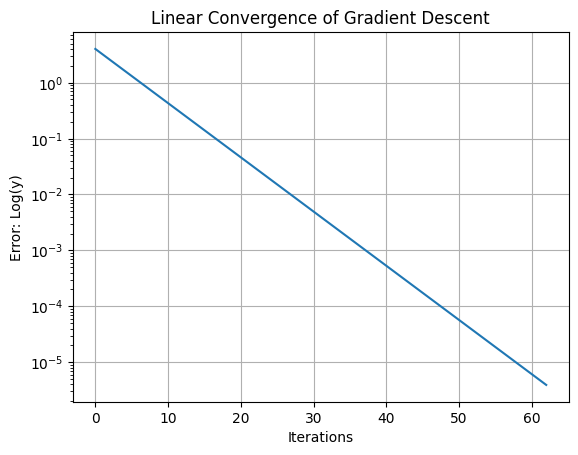

In [6]:
# x^2 is a convex function.
def f(x):
    return x**2 + 4*x + 4

# The function is smooth and differentiable.
def df(x):
    return 2*x + 4


x, path = gradientDescent(start=2)
fig, ax = plt.subplots()

x = np.arange(len(path))
path = np.asarray(path)
true = -2
relative_error = abs(path - true)
plt.plot(x, relative_error)
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Error: Log(y)")
plt.title("Linear Convergence of Gradient Descent")
plt.grid(True);

# Exact Line Search Deriviations

Derive the exact line search step size for a quadratic $f (x) = \frac{1}{2}x^TAx − b^Tx$: show the optimal step is $\alpha_k = \frac{\lVert r_k \rVert^2}{(r^T_kAr_k)}$ where $r_k = −\nabla f(x_k)$.

Unlike in the previous two proofs in which the step size was fixed, our goal is now to find the most optimal step size for the general quadratic function $f(x) = \frac{1}{2}x^T Ax - b^T$. The equation that we must minimize to find the optimal step size is as follows:
$$\alpha_k = \arg \min_{\alpha \geq 0} f(x_k - \alpha d_k)$$
where $x_k$ is the current point, $d_k$ is the search direction, and $\alpha$ is the step size. For gradient descent, the search direction $d_k = -\nabla f(x_k) = r_k$, also known as the residual. As a result, we can define our update function (normally $x_{k + 1} = x_k - \alpha \nabla f(x_k)$) as follows:
$$x_{k + 1} = x_k + \alpha r_k$$

As we want to isolate the scaler $\alpha$, let's substitute $(x_{k + 1} = x_k + \alpha r_k)$ into $f$, denoted as $\phi(\alpha)$.
$$\phi(\alpha) = \frac{1}{2}(x_k + \alpha r_k)^TA(x_k + \alpha r_k) − b^T(x_k + \alpha r_k)$$
$$\phi(\alpha) = \frac{1}{2}(x_k^T + \alpha r_k^T)A(x_k + \alpha r_k) - b^Tx_k - b^T\alpha r_k$$
$$\phi(\alpha) = \frac{1}{2}x_k^TAx_k + \frac{1}{2}x_k^TA\alpha r_k + \frac{1}{2}\alpha r_k^TAx_k + \frac{1}{2}\alpha^2 r_k^TA r_k - b^Tx_k - \alpha b^T r_k$$
$$\phi(\alpha) = \frac{1}{2}x_k^TAx_k - b^Tx_k + \frac{1}{2}x_k^TA\alpha r_k + \frac{1}{2}\alpha r_k^TAx_k + \frac{1}{2}\alpha^2 r_k^TA r_k - \alpha b^T r_k$$
$$\phi(\alpha) = \frac{1}{2}x_k^TAx_k - b^Tx_k + \alpha(\frac{1}{2}x_k^TA r_k + \frac{1}{2} r_k^TAx_k - b^T r_k) + \frac{1}{2}\alpha^2 r_k^TAr_k$$

There are a couple observations that can help us simplify the above equation. First, $x_k^TA r_k$ is equivalent to a scaler, $x_k^TA r_k = (x_k^TA r_k)^T$. Furthermore, as $A$ is symmetric, $A = A^T$. As a result, $(x_k^TA r_k)^T = r_k^T A^T x_k = r_k^TAx_k$. Next, the first two terms make up $f(x)$ and can be substituted as a result:
$$\phi(\alpha) = f(x) + \alpha(x_k^TA - b^T)r_k + \frac{1}{2}\alpha^2 r_k^TAr_k$$

Notice that $(x^T_kA - b^T)^T = (Ax_k - b)$, furthermore recall that $\nabla f(x_k) = Ax_k - b = -r_k$. As a result, $-r^T_k = x^T_kA - b^T$. Lastly recall that $-r^T_k r_k = -\lVert r_k \rVert^2$. Therefore:
$$\phi(\alpha) = f(x) - \alpha \lVert r_k \rVert^2 + \frac{1}{2}\alpha^2 r_k^TAr_k$$

As our goal is to find $\arg \min_{\alpha \geq 0}$. We simply need to take the derivative of $\phi(\alpha)$ with respect to $\alpha$, $\frac{d\phi}{d\alpha}$, set $\frac{d\phi}{d\alpha} = 0$, and then solve for $\alpha$
$$\frac{d\phi}{d\alpha} = (f(x) - \alpha \lVert r_k \rVert^2 + \frac{1}{2}\alpha^2 r_k^TAr_k)\frac{d}{d\alpha}$$
$$\frac{d\phi}{d\alpha} = -\lVert r_k \rVert^2 + \alpha r_k^TAr_k = 0$$
$$\alpha r_k^TAr_k = \lVert r_k \rVert^2$$
$$\alpha = \frac{\lVert r_k \rVert^2}{r_k^TAr_k}\ \ \square$$

# Implementation

## Gradient Descent, Line Search, and Nesterov Comparisons

### Definitions

Nesterov's Gradient
$w$ is weight, $\beta$ is momentum and $v_{t-1}$ is previous velocity term, $\eta$ is learning rate.
\
Calculate Look Ahead Point
$$w_{\text{look ahead}} = w - \beta * v_{t-1}$$
Calculate Gradient at Look Ahead
$$\text{Gradient} = \nabla f(w_{\text{look-ahead}})$$
Update Velocity Term
$$v_t = \beta*v_{t-1} + \eta *\text{gradient}$$
Update Weights
$$w = w - v_t$$
Nesterov reduces oscillations around minimum, and often reaches convergence faster

In [9]:
tol = eps
def f(A, b, x):
    return 0.5 * x.T @A@x - b.T@x
def Basic_Gradient(A, b, start, learningRate, iterations, exact):
    x = start.copy()
    errors = []
    path = [x]
    for i in iterations:
        gradient = A @ x - b
        x = x - learningRate * gradient
        error = np.linalg.norm(x-exact) #L2 NORM
        if (error)<tol:
            errors.extend([errors[-1]]*(len(iterations)-len(errors)))
            break
        errors.append(error)
        path.append(x)
    return x, errors, path
def gradient_with_ExactLine(A, b, start, iterations, exact):
    x = start.copy()
    errors = []
    path =[x]
    for i in iterations:
        gradient = A @ x -b
        #check for convergence using norm of the gradient 
        if np.linalg.norm(gradient) < tol:
            # print(f"Converged")
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
            #return x
        numerator = (gradient @ gradient) 
        denominator = (gradient.T) @ A @ gradient 
        alpha = numerator/denominator
        x = x- alpha * gradient
        errors.append(np.linalg.norm(x - exact)) 
        path.append(x)
    return x, errors, path
def nesterovs_gradient(A, b, start, learningRate, iterations, exact, momentum = 0.9):
    x = start.copy()
    y = start.copy() #look ahead point
    velocity = np.zeros_like(start)
    errors = []
    path = [x]
    for i in iterations:
        #step in direction of previous velocity
        lookAhead = x+momentum * velocity
        #gradient at look ahead
        gradient = A@ lookAhead - b 
        #update velocity 
        velocity = momentum * velocity - learningRate * gradient 
        #update position
        x =  x + velocity
        error = np.linalg.norm(x - exact)
        if error<tol:
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
        errors.append(error)
        path.append(x)
    return x, errors, path

<>:35: SyntaxWarning: invalid escape sequence '\k'
<>:35: SyntaxWarning: invalid escape sequence '\k'
C:\Users\stitgenn1808\AppData\Local\Temp\ipykernel_30760\2192906625.py:35: SyntaxWarning: invalid escape sequence '\k'
  ax_error.set_title(f"A Dimension Size {size} x {size}, $\kappa = {k}:.2f$")


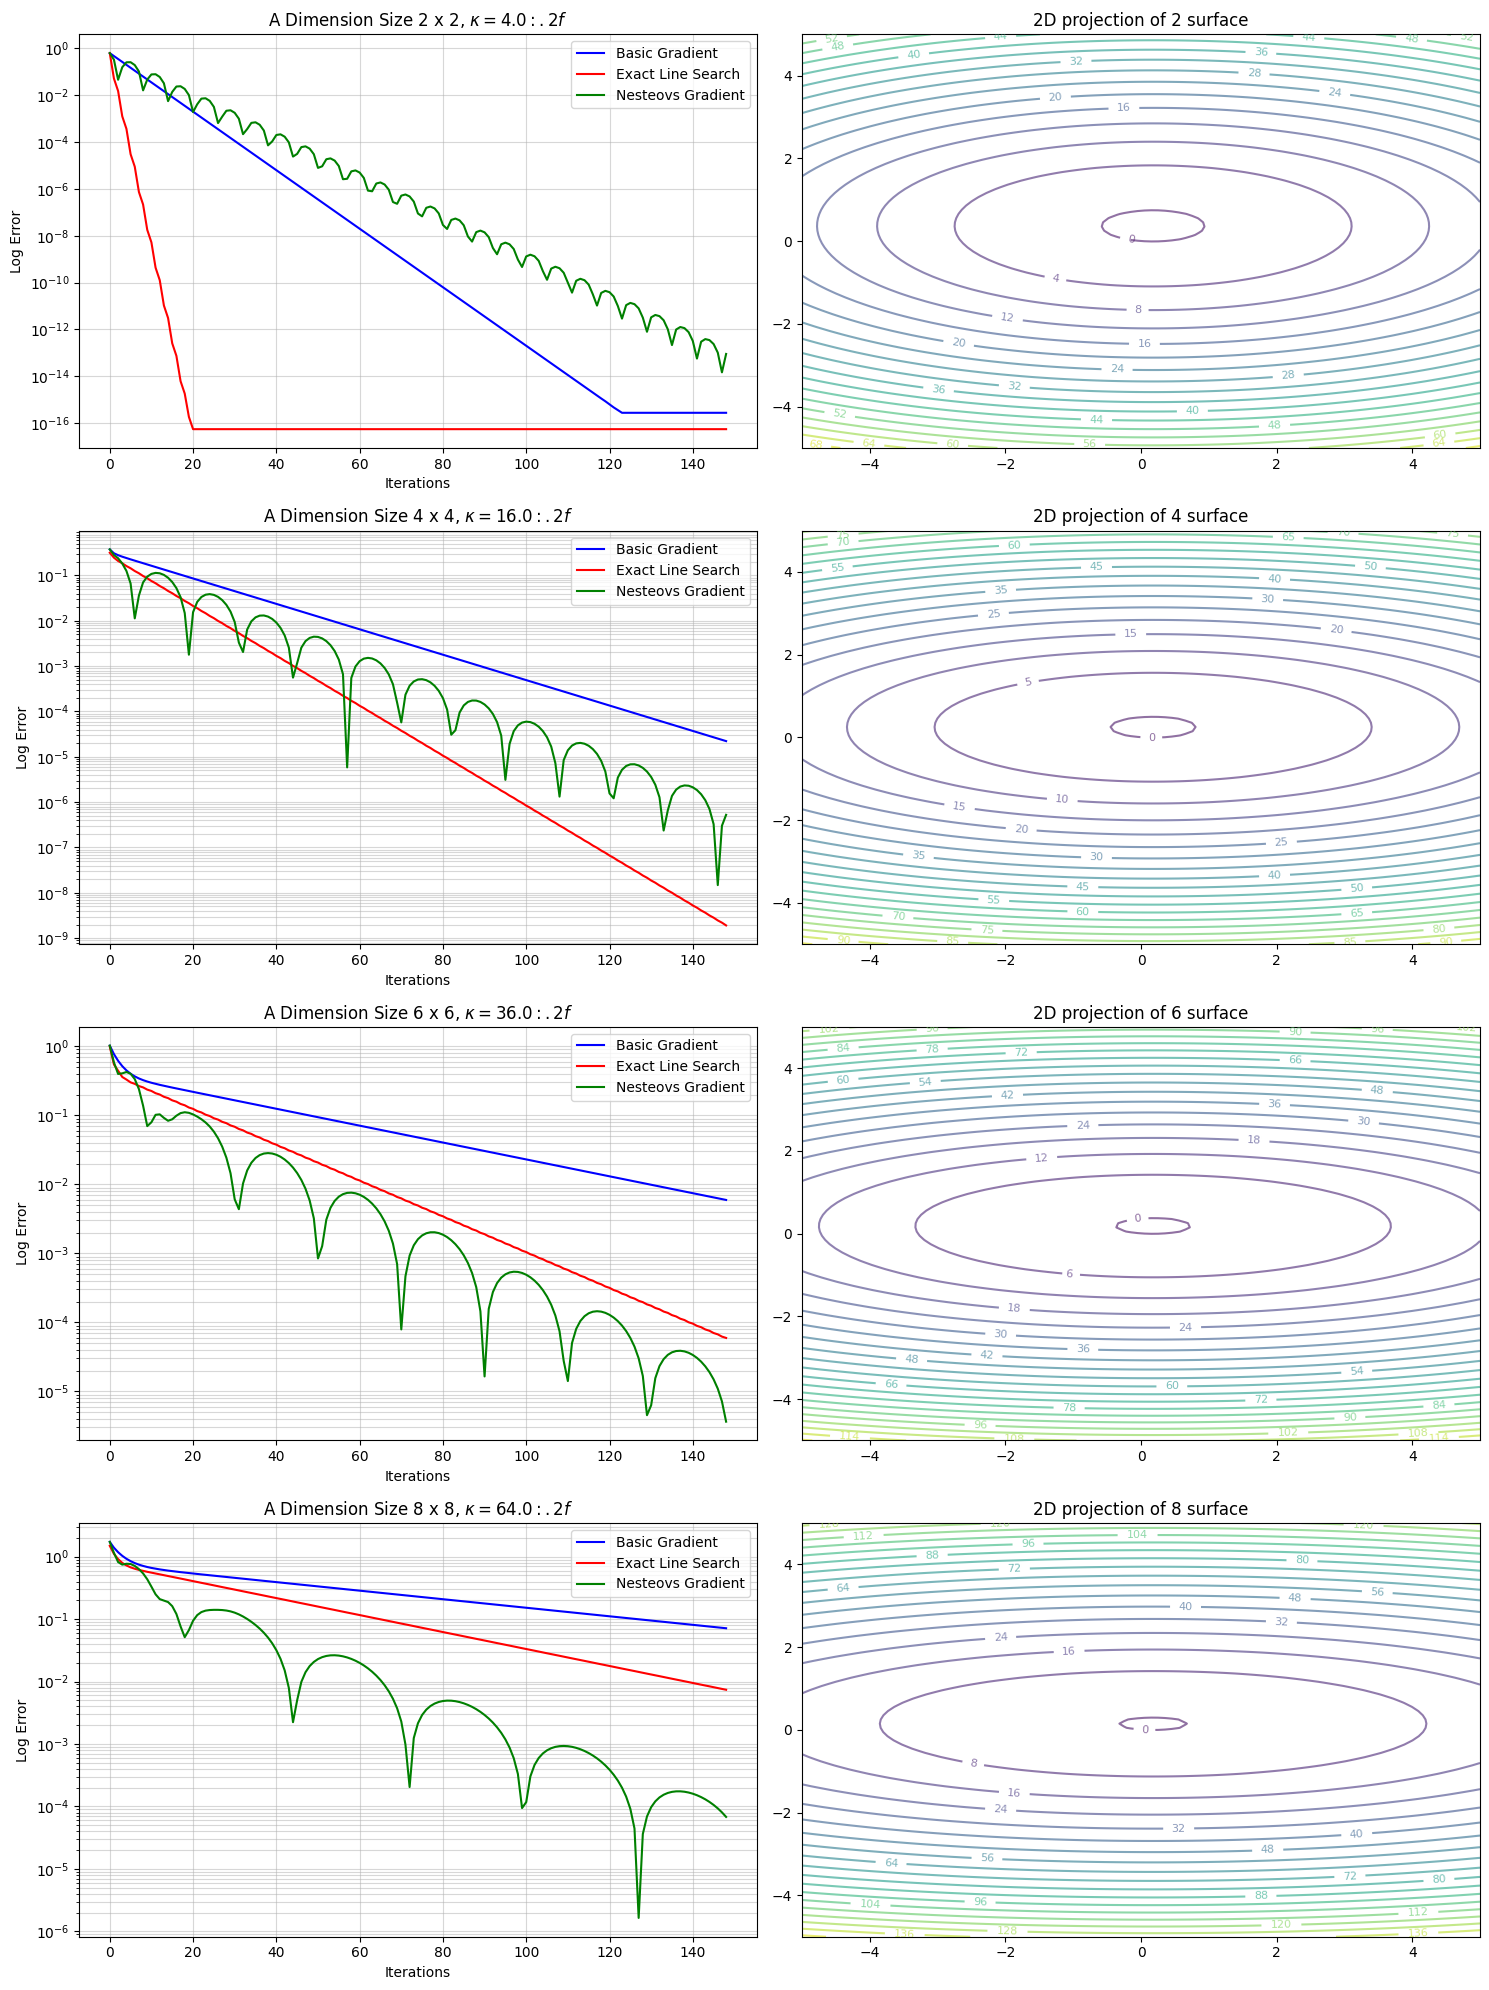

In [12]:
""""
Each Function is the same
NAG excels when condition number is large, 
Condition Number is $k = frac{simga_{max}}{sigma_{min}}$
"""

i = 0
maxDimensions = 6
fig, axs = plt.subplots((maxDimensions-2), 2, figsize=(15, 5 * (maxDimensions -2)))

b_base = np.random.randn(2)
size = 2
for j in range(maxDimensions - 2):
    eigenValues = np.linspace(1, size**2, size)
    A = np.diag(eigenValues)
    b = np.random.randn(size)
    b[:2] = b_base
    x_initial = np.random.randn(size)
    exact = np.linalg.solve(A,b)
    
    L = np.max(np.linalg.eigvals(A))
    learningRate = 1/L #Lipschitz constant 
    iterations = np.arange(1,150,1)
    exact = np.array([np.linalg.solve(A,b)])
    
    ax_error = axs[j,0]
    ax_func = axs[j,1]
    
    xBG, errorsBG, _bg= Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
    xGE, errorsGE,_ge = gradient_with_ExactLine(A, b, x_initial, iterations, exact)

    m = 0.9
    k = np.max(eigenValues)/np.min(eigenValues)
    xNG, errorsNG, _nag= nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact, momentum =m)
    ax_error.set_title(f"A Dimension Size {size} x {size}, $\kappa = {k}:.2f$")
    ax_error.semilogy(np.arange(len(errorsBG)), errorsBG, 'b-', np.arange(len(errorsGE)), errorsGE, 'r-', np.arange(len(errorsNG)), errorsNG, 'g-')
    ax_error.set_xlabel('Iterations')
    ax_error.set_ylabel('Log Error')
    ax_error.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
    ax_error.grid(True, which="both", ls="-", alpha=0.5)
    
    nPts = 100
    u = np.linspace(-5,5,nPts)
    x1, x2 = np.meshgrid(u,u)
    X_cords = np.vstack([x1.flatten(), x2.flatten()])
    A_2d = A[:2, :2] #slice away to get the 2d grid
    B_2d = b[:2]
    z = 0.5 * np.diag(X_cords.T@ A_2d @X_cords) - B_2d.T@X_cords
    z = z.reshape(nPts, nPts)
    
    contour = ax_func.contour(x1, x2, z, levels=20, cmap='viridis', alpha = 0.6)
    ax_func.clabel(contour, inline = True, fontsize=8)
    ax_func.set_title(f"2D projection of {size} surface")

    liPath = [
        (_bg, 'winter_r', 'vanilla'),
        (_ge, 'CMRmap', 'Exact Line'),
        (_nag, 'bone_r', 'NAG')
    ]
    # for j, jc, jl in liPath:
    #     j = np.array(j)
    #     step_indices = np.arange(len(j))
    #     scatter =ax_func.scatter(j[:,0], j[:,1], c=step_indices, cmap=jc, s=15, edgecolors='none')
    #     cbar = fig.colorbar(scatter)
        
    size += 2
plt.tight_layout()
plt.show()

## Gradient Descent Path Visualization with Rosenbrock

In [14]:
tol = eps
a = 1
b = 100
def Rosenbrock(x, y, a = 1, b = 100):
    value = (a-x)**2 + b*(y-x**2)**2
    return value
def gradientRosenbrock(x,y, a = 1, b = 100):
    df_dx = -2*a + 4*b*x*(x**2 - y) + 2*x
    df_dy = 2 * b * (-x**2 + y)
    return np.array([df_dx, df_dy])

In [15]:
def function_basic_gradient(func, grad, exact, start, learningRate, iterations):
    x = np.array(start)
    errors = []
    history = []
    for i in iterations:
        gradient = grad(x[0],x[1])
        x = x - learningRate * gradient
        error = np.linalg.norm(x - exact)
        errors.append(error) #l2 norm
        history.append(x)
    return x, errors, history
#since we cannot use minimize_vector
def exactLineSearch(func, x, direction, bounds=[0,0.05], pts=500):
    alphas = np.linspace(bounds[0], bounds[1], pts) 
    values = [func((x+alpha*direction)[0], (x+alpha*direction)[1]) for alpha in alphas]
    best = alphas[np.argmin(values)]
    return best
def run(meth,func, gradient, start, exact, iterations, lr=0.001):
    x = start.copy()
    history = [x.copy()]
    errors = []
    v = np.zeros_like(x) #velocities
    m = 0.9 #momentum
    for i in iterations:
        grad = gradient(x[0], x[1])
        if np.linalg.norm(grad)<tol:
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
        if meth=='van':
            lr = 0.002
            x = x-lr*grad
        elif meth=='EL':
            alpha = exactLineSearch(func, x, -grad)
            x = x-alpha*grad
        elif meth=='nest':
            lookAhead = x+ m *v
            gradAhead = gradient(lookAhead[0], lookAhead[1]) 
            v = m * v - lr * gradAhead
            x = x+ v
        history.append(x)
        errors.append(np.linalg.norm(x-exact))
    return history, errors, x
exact = np.array([a, a**2])
start = [0,0]

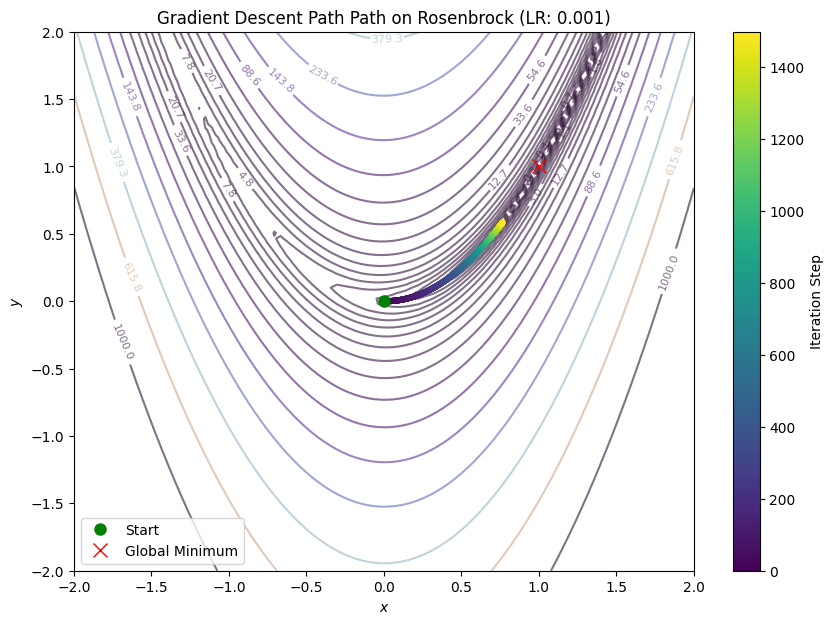

In [16]:
exact = np.array([a, a**2])
lr = 0.001
iterations = np.arange(1,1500)
v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)
path = np.array(path)

#colorbar to show time
step_indices = np.arange(len(path))
plt.figure(figsize=(10,7))

#Contours Rosenbrock
levels = np.logspace(-1,3,20)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2,2,100)
X, Y = np.meshgrid(x,y)
Z = Rosenbrock(X, Y)
contour = plt.contour(X, Y, Z, levels=levels, cmap='twilight_shifted', alpha=0.6)
plt.clabel(contour, inline = True, fontsize=8)
# plot the line 
plt.plot(path[:,0], path[:,1], color='black', lw=1, alpha=0.3, zorder=2)

scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='viridis', s=20, edgecolors='none', zorder=3)
cbar = plt.colorbar(scatter)
cbar.set_label('Iteration Step')
plt.plot(path[0,0], path[0,1], 'go', markersize=8, label='Start', zorder=5)
plt.plot(exact[0], exact[1], 'rx', markersize=10, label='Global Minimum', zorder=5)
plt.title(f'Gradient Descent Path Path on Rosenbrock (LR: {lr})') 
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show();


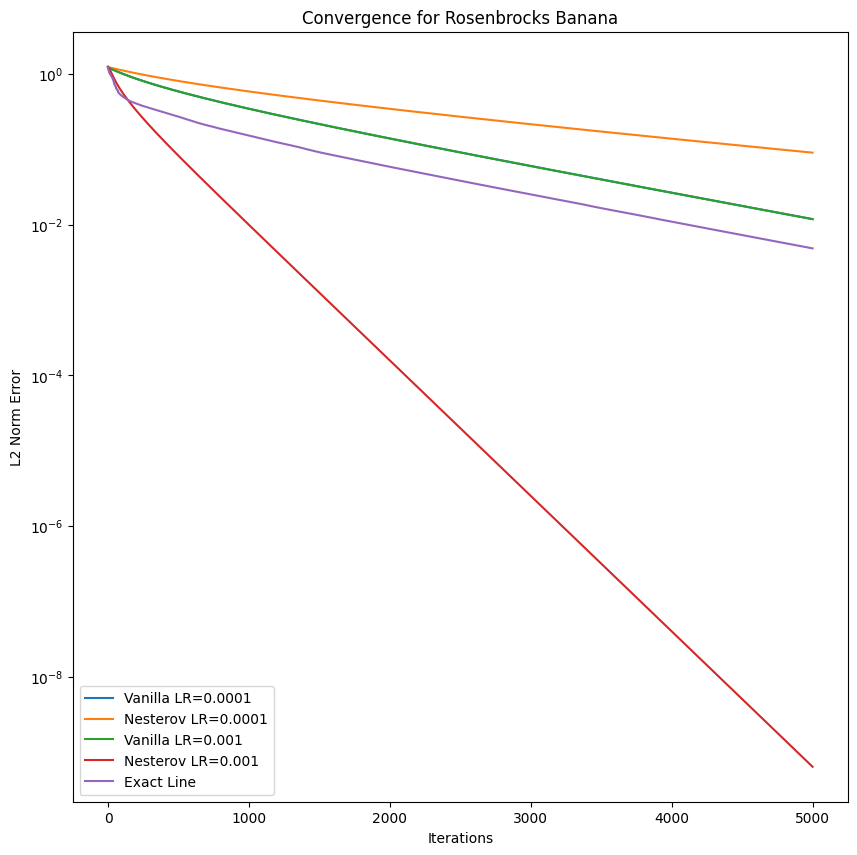

In [23]:
#Graphing The Convergence Rates for Different Gradient Descent Methods and altering the learningRate for NAG and Vanilla
its = range(1,5000)
lrs = [0.0001,0.001]
start = [0.25, 0]
exact = [1,1]
fig= plt.figure(figsize=(10, 10))
ax_error = plt
for l in lrs:
    #print(l)
    histVan, errVan, xVan = run('van', Rosenbrock, gradientRosenbrock, start, exact, its, l)
    histN, errN, xN = run('nest', Rosenbrock, gradientRosenbrock, start, exact, its, l)
    ax_error.plot(errVan, label=f'Vanilla LR={l}')
    ax_error.plot(errN, label=f'Nesterov LR={l}')
histEL, errEL, xEL = run('EL', Rosenbrock,gradientRosenbrock, start, exact, its)
ax_error.plot(errEL, label=f'Exact Line')
ax_error.yscale('log')
ax_error.legend()
ax_error.ylabel('L2 Norm Error')
ax_error.xlabel('Iterations')
ax_error.title('Convergence for Rosenbrocks Banana')
plt.show();

[-0.2641 -0.51  ]


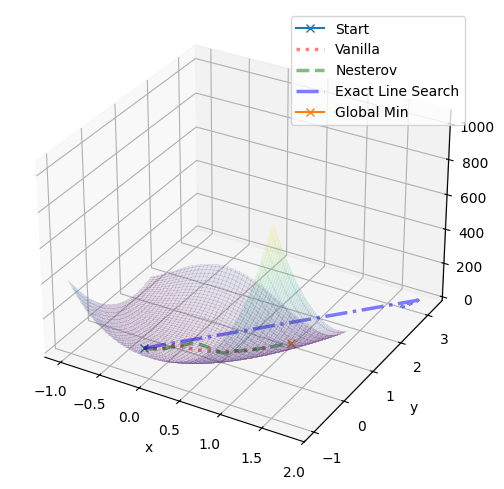

In [17]:
plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
exact = [1, 1]
its = np.arange(1,1000)
x = np.linspace(-1, 1.5, 100)
y = np.linspace(-1,1.5,100)
X, Y = np.meshgrid(x,y)
Z = Rosenbrock(X, Y)
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, alpha = 0.10, antialiased=False)
histVan, errVan, xVan = run('van', Rosenbrock, gradientRosenbrock, start, exact, its, 0.001)
path_xy = np.array(histVan)
path_z = Rosenbrock(path_xy[:,0], path_xy[:,1])
paths = [
    ('van', 'red', 'dotted', 'Vanilla'),
    ('nest', 'green','dashed', 'Nesterov'),
    ('EL', 'blue', 'dashdot','Exact Line Search')
]
start = (np.random.randn(2))
start[1] = (-1)*np.round(start[1], 2)
start[0] = np.round(start[0], 4) + (1/10)
print(start)
ax.plot(start[0], start[1], Rosenbrock(start[0], start[1]), marker='x', label='Start')
for meth, mC, lStyle, label in paths:
    #print(label)
    hist, err, end = run(meth, Rosenbrock, gradientRosenbrock, start, exact, its, 0.001)
    path_xy = np.array(hist)
    path_z = Rosenbrock(path_xy[:,0], path_xy[:,1])
    ax.plot(path_xy[:,0], path_xy[:,1], path_z, color=mC, linestyle=lStyle, linewidth=2.5, alpha = 0.5, label=label)

ax.plot(exact[0], exact[1], Rosenbrock(exact[0], exact[1]), marker='x', label='Global Min')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.legend()
plt.show();

## Gradient Descent Applied to Rastrigin

$$f(x) = An +\sum_{i=1}^n [x_i^2 - A cos(2\pi x_i)]$$
where $A = 10$ and $x_i \in [-5.12, 5.12]$

Rastrigin is a non-convex function meaning the application of gradient descent can lead to the algorithm getting stuck in local minima or saddle points
In exploration of this problem we first plotted the a bunch of different learning rates and their impact on the convergence rate of the Vanilla Gradient Descent. This resulted in the best learning rate being $LR=0.01 \text{ Minimum Error } = 0.5779991401371611$. 
Then we created a for loop to test a bunch of different momentums and learning rates to find the best one for Nesterovs [in another file]. From those tests we got the values $M={0.5}, LR={0.019}, \text{ Minimum Error } \approx {0.00164}$. 
However while running that for loop we also decided to retest vanilla, and got back the better values of $LR=0.029, \text{ Minimum Error } \approx 0.0204$
Then we used the 3 previously defined gradient descent methods and plotted their convergence rates next to their path of convergence.

In [18]:
def Rastrigin(x, y):
    A = 10
    #return A* len(X) + sum([(x**2 - A * np.cos(2* np.pi *x)) for x in X])
    return A * 2 + (x**2 - A *np.cos(2*np.pi *x)) + (y**2 - A*np.cos(2*np.pi *y))
def gradientRastrigin(x, y):
    df_one = 2*x + 2*np.pi * 10 * np.sin(2*np.pi * x)
    df_two = 2*y + 2*np.pi *10 *np.sin(2*np.pi * y)
    return np.array([df_one, df_two])
def runA(meth,func, gradient, start, exact, iterations, lr=0.001, m = 0.75):
    x = start.copy()
    history = [x.copy()]
    errors = []
    v = np.zeros_like(x) #velocities
    for i in iterations:
        grad = gradient(x[0], x[1])
        if np.linalg.norm(grad)<tol:
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
        if meth=='van':
            x = x-lr*grad
        elif meth=='EL':
            alpha = exactLineSearch(func, x, -grad)
            x = x-alpha*grad
        elif meth=='nest':
            lookAhead = x+ m *v
            gradAhead = gradient(lookAhead[0], lookAhead[1]) 
            v = m * v - lr * gradAhead
            x = x+ v
        history.append(x.copy())
        errors.append(np.linalg.norm(x-exact))
    return history, errors, x

LR=0.0001 0.9949586376523362
LR=0.001 0.9949586376523349
LR=0.0025 0.9949586376523348
LR=0.01 0.5779991401371611
LR=0.1 0.8724001199306322


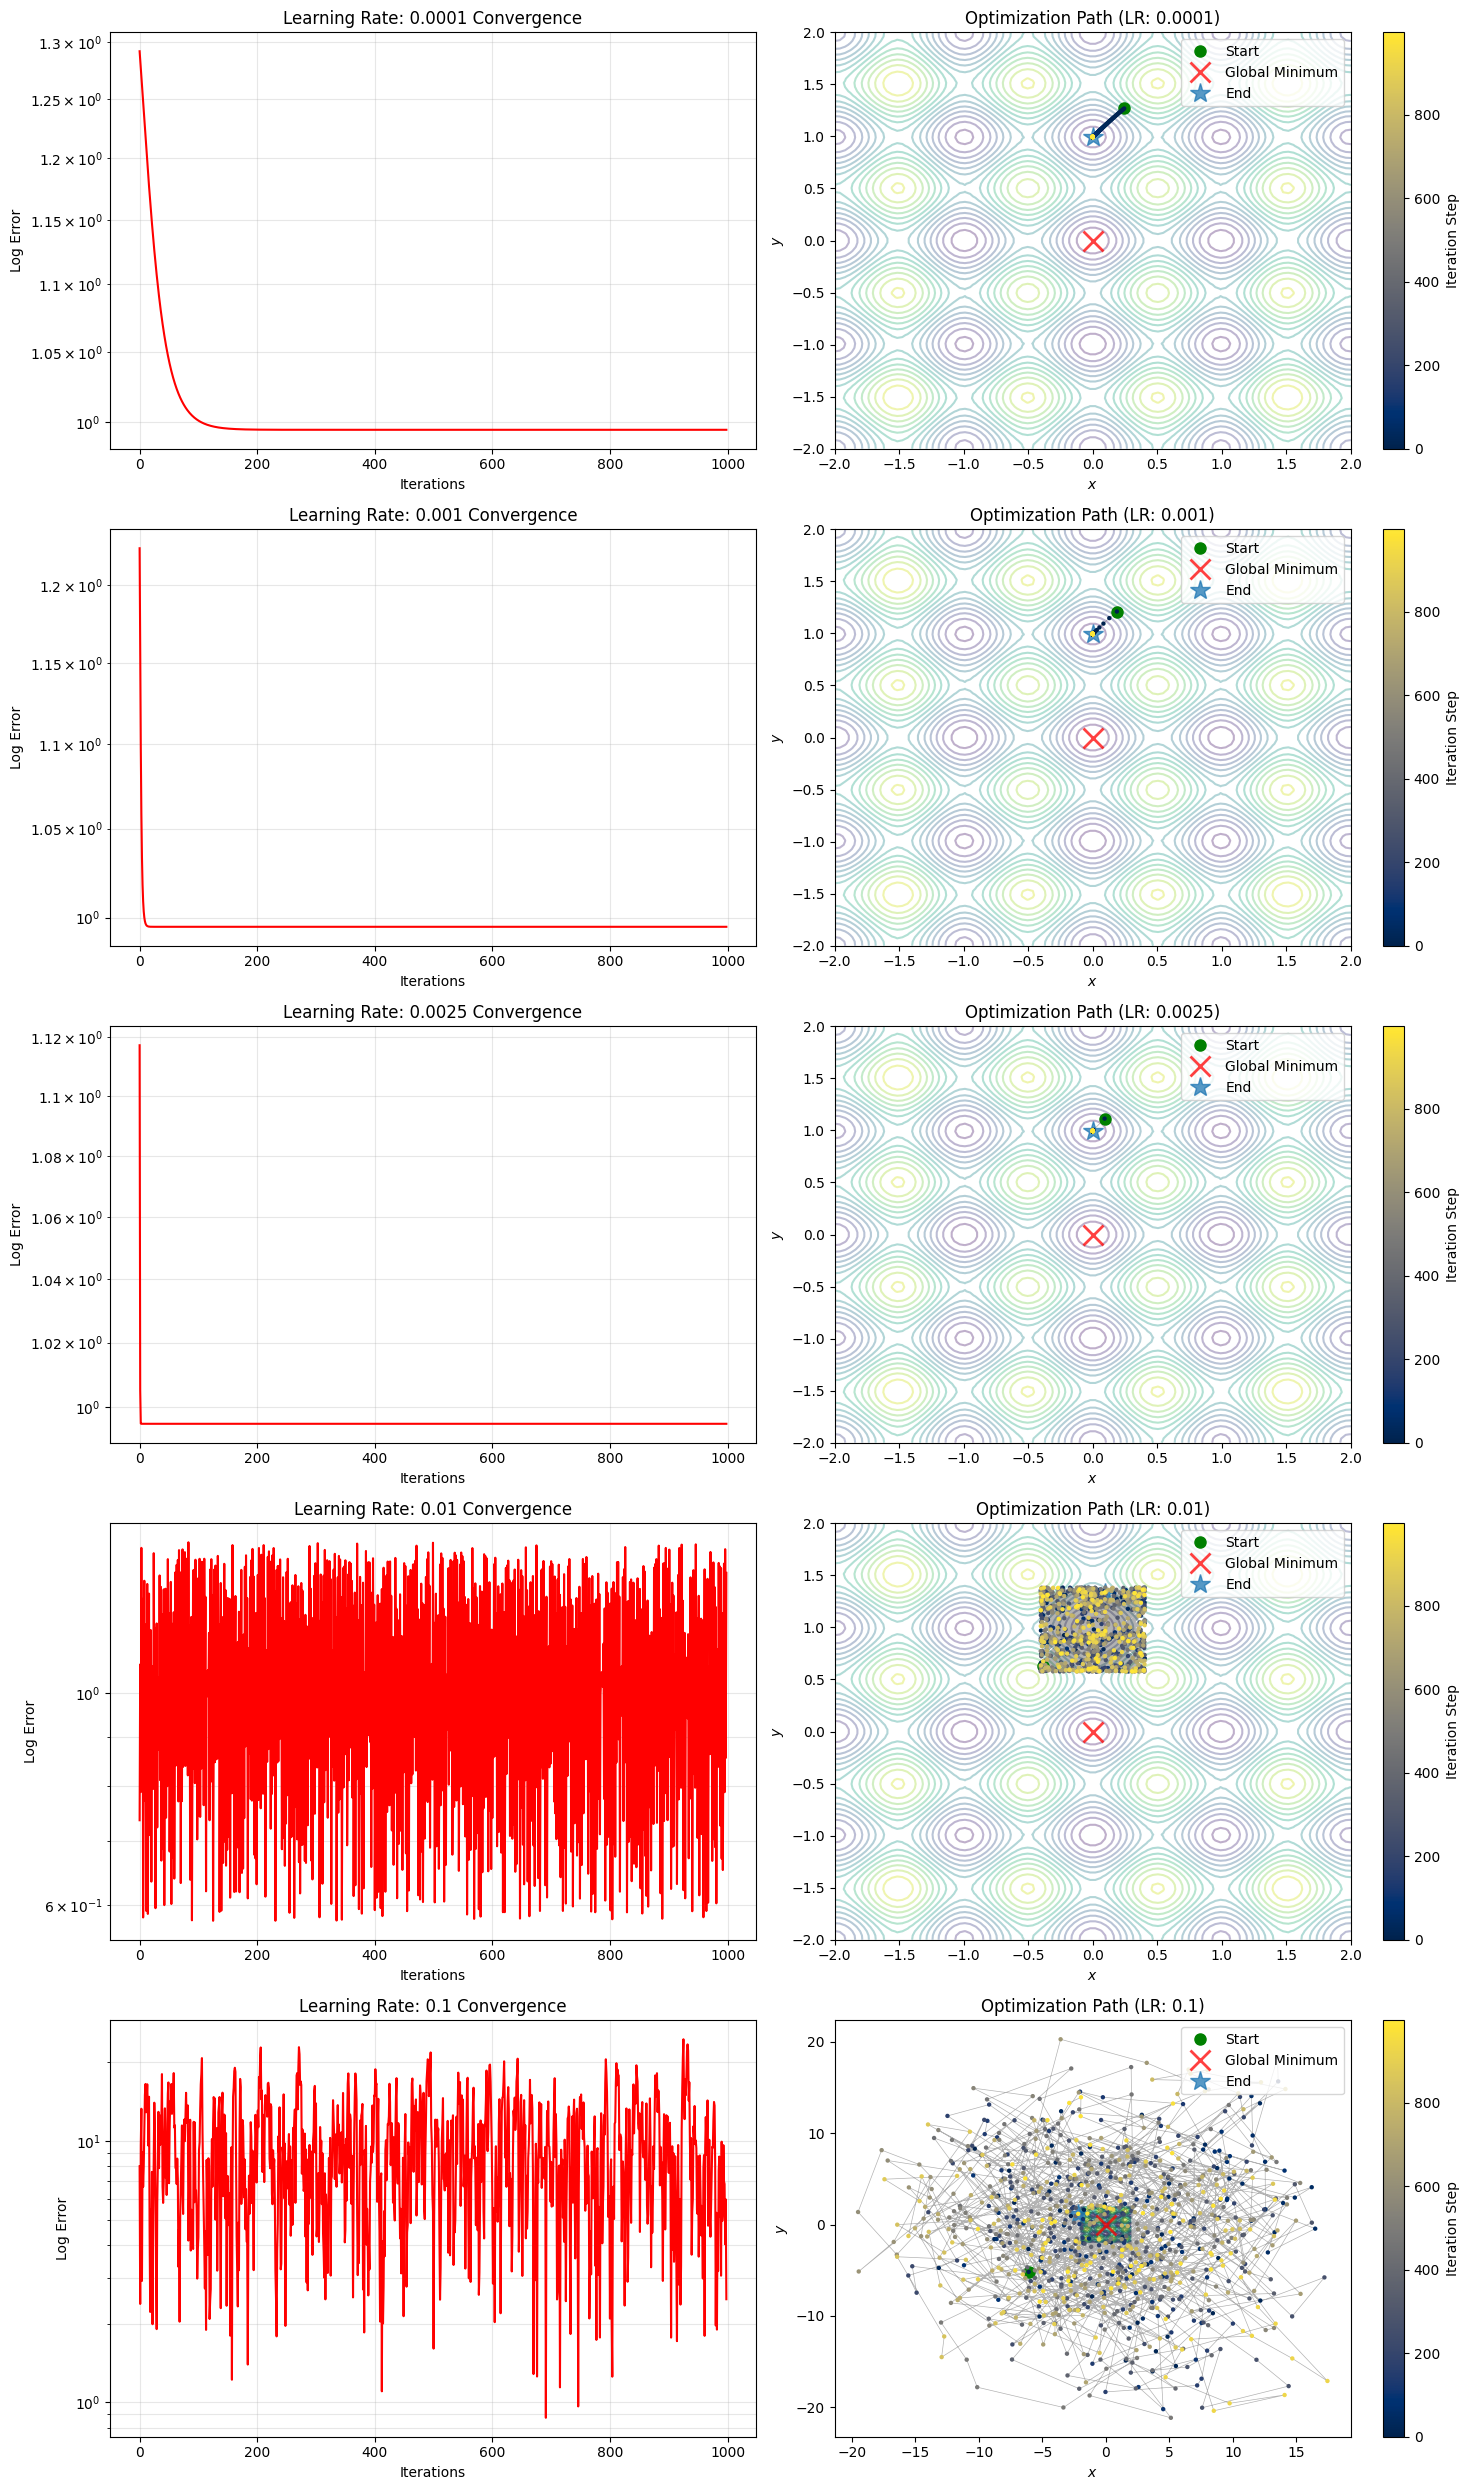

In [19]:
"""
Graphing Log Error Vs Iterations for Different Learning Rates and The Path of the Gradient Descent 
"""
iterations = range(1,1000)
exact = np.array([0,0])
lrs = [0.0001, 0.001,0.0025, 0.01, 0.1]
fig, axs = plt.subplots(len(lrs), 2, figsize=(15, 5*len(lrs)))
start = [0.25, 1.275]
for i, lr in enumerate(lrs):
    
    v, errors, path = function_basic_gradient(Rastrigin, gradientRastrigin, exact, start, lr, iterations)
    ax_error = axs[i,0]
    ax_path = axs[i,1]
    # ERROR 
    ax_error.semilogy(range(len(errors)), errors, 'r-')
    ax_error.set_xlabel('Iterations')
    ax_error.set_ylabel('Log Error')
    ax_error.set_title(f'Learning Rate: {lr} Convergence')
    ax_error.grid(True, which="both", ls="-", alpha = 0.3)

    # PATH PLOT
    path = np.array(path)
    x_range = np.linspace(-2,2,100)
    y_range = np.linspace(-2,2,100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = Rastrigin(X,Y)
    ax_path.contour(X, Y, Z, levels = 15, cmap='viridis', alpha=0.35)
    
    #trajectory line
    ax_path.plot(path[:,0], path[:,1], 'k-', linewidth=0.5, alpha = 0.3) 
    step_indices = np.arange(len(path))
    scatter = ax_path.scatter(path[:,0], path[:,1], c=step_indices, cmap='cividis', s=10, edgecolors='none', zorder=3)
    
    cbar = fig.colorbar(scatter, ax = ax_path)    
    cbar.set_label('Iteration Step')
    ax_path.plot(path[0,0], path[0,1],'go', label='Start', markersize=8)
    ax_path.plot(exact[0],exact[1],'rx', markersize=15, alpha = 0.75, label='Global Minimum', markeredgewidth=2)
    ax_path.plot(v[0], v[1], '*', markersize=15, alpha = 0.75, label='End')
    ax_path.set_title(f'Optimization Path (LR: {lr})')
    ax_path.set_xlabel('$x$')
    ax_path.set_ylabel('$y$')
    ax_path.legend(loc='upper right')
    print(f"LR={lr} {np.min(errors)}")
plt.tight_layout()
plt.savefig('LearningRates.png')
plt.show();

Then we plot the 3 Different Converge Rates on the Same Plot

Text(0.5, 1.0, 'Gradient Descent on Rastrigin Convergence Rate @ Start = [0.25, 1.275], LR = 0.03, M = 0.75')

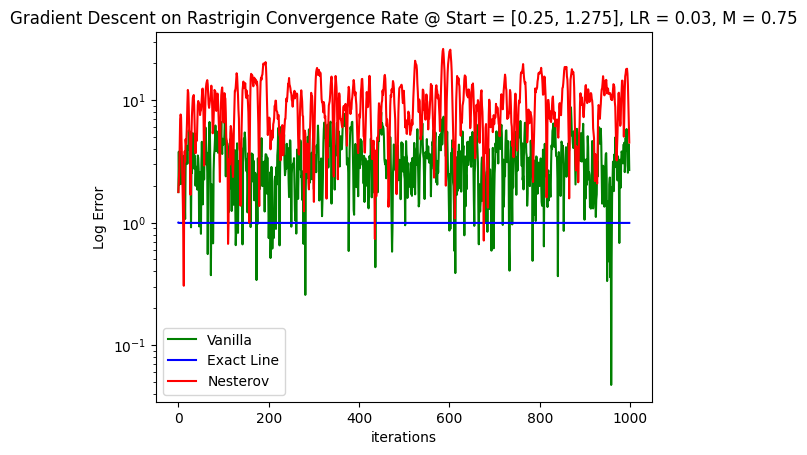

In [20]:
lr = 0.03
iterations = np.arange(1, 1000)
start = [0.25, 1.275]
exact = [0,0]
m = 0.75
histV, errV, xv = runA('van',Rastrigin, gradientRastrigin, start, exact, iterations, lr)
histEl, errEl, xE = runA('EL',Rastrigin, gradientRastrigin, start, exact, iterations, lr)
histNest, errN, xN = runA('nest', Rastrigin, gradientRastrigin, start, exact, iterations, lr,m)
plt.semilogy(np.arange(len(errV)), errV, 'g-', np.arange(len(errEl)), errEl, 'b-', np.arange(len(errN)), errN, 'r-')
plt.legend(['Vanilla', 'Exact Line', 'Nesterov'])
plt.xlabel('iterations')
plt.ylabel('Log Error')
plt.title(f'Gradient Descent on Rastrigin Convergence Rate @ Start = {start}, LR = {lr}, M = {m}')

van, 0.28672418270970207
EL, 0.9949586384832373
nest, 0.11889856963144071


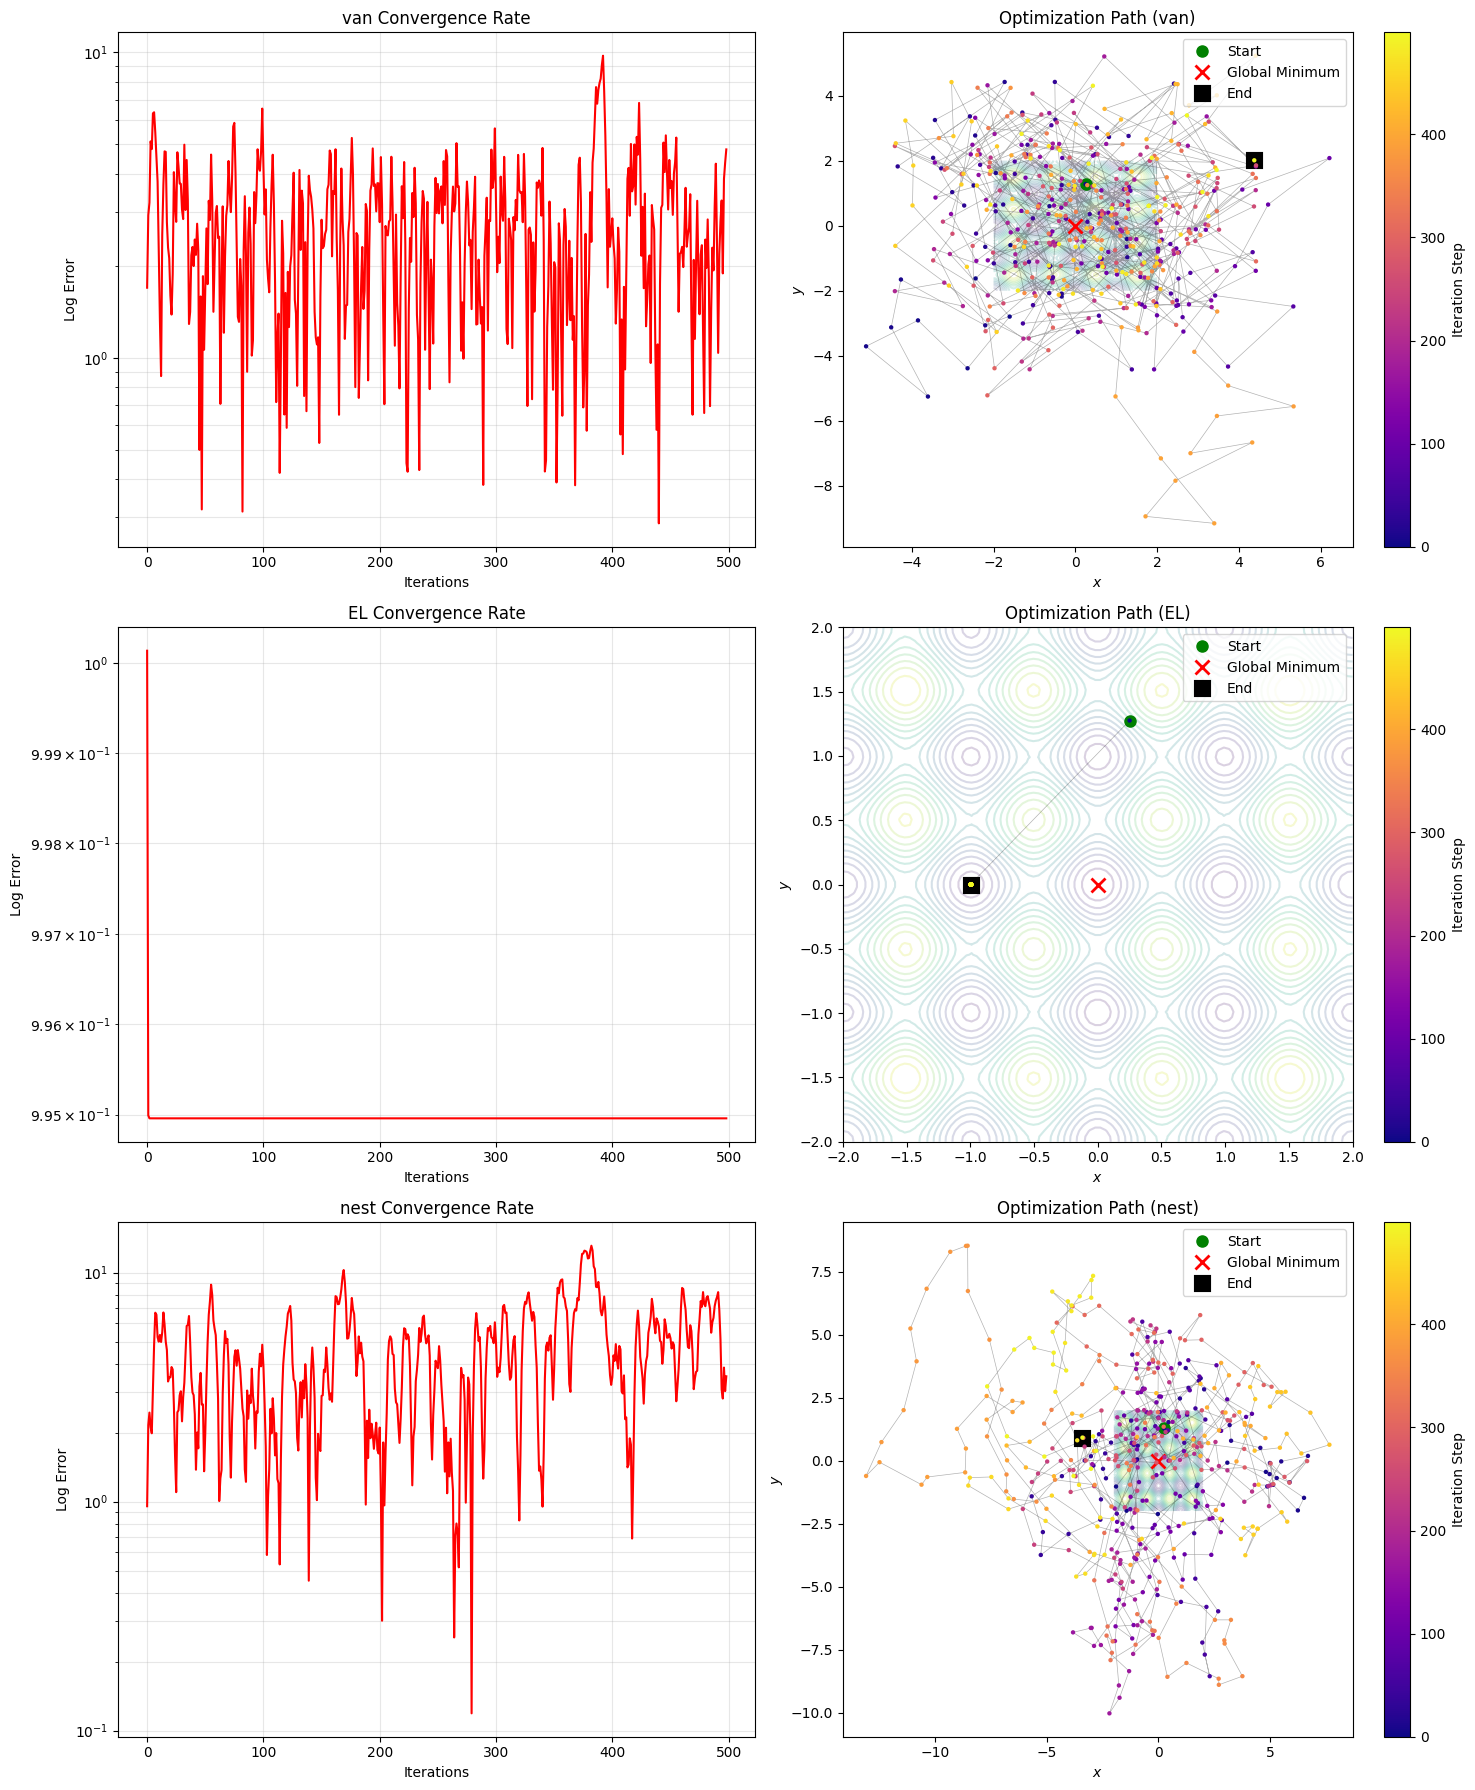

In [21]:
"""
Graphing Log Error Vs Iterations for Different Gradient Descent Methods and The Paths ontop of the Rastrigin Function
"""
its = range(1,500)
exact = np.array([0,0])
start = [0.25, 1.275]
meths = ['van', 'EL', 'nest']
fig, axs = plt.subplots(len(meths), 2, figsize=(15, 6*len(meths)))
lr = 0.029 #0.05
for i in range(len(meths)):
    if meths[i] == 'nest':
        lr = 0.019
    path, errors, v = runA(meths[i],Rastrigin, gradientRastrigin, start, exact, its, lr, 0.5)
    path = np.array(path)
    errors = np.array(errors)
    ax_error = axs[i,0]
    ax_path = axs[i,1]
    print(f"{meths[i]}, {np.min(errors)}")
    # ERROR 
    ax_error.semilogy(range(len(errors)), errors, 'r-')
    ax_error.set_xlabel('Iterations')
    ax_error.set_ylabel('Log Error')
    ax_error.set_title(f'{meths[i]} Convergence Rate')
    ax_error.grid(True, which="both", ls="-", alpha = 0.3)
    #ax_error.legend()
    # PATH PLOT
    path = np.array(path)
    x_range = np.linspace(-2,2,100)
    y_range = np.linspace(-2,2,100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = Rastrigin(X,Y)
    ax_path.contour(X, Y, Z, levels = 15, cmap='viridis', alpha=0.2)
    #trajectory line
    ax_path.plot(path[:,0], path[:,1], 'k-', linewidth=0.5, alpha = 0.3) 
    step_indices = np.arange(len(path))
    scatter = ax_path.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=10, edgecolors='none', zorder=3)
    cbar = fig.colorbar(scatter, ax = ax_path)    
    cbar.set_label('Iteration Step')
    ax_path.plot(path[0,0], path[0,1],'go', label='Start', markersize=8)
    ax_path.plot(exact[0],exact[1],'rx', markersize=10, label='Global Minimum', markeredgewidth=2)
    ax_path.plot(v[0], v[1], 's', color='black', markersize=10, label='End', markeredgewidth=2.25)
    ax_path.set_title(f'Optimization Path ({meths[i]})')
    ax_path.set_xlabel('$x$')
    ax_path.set_ylabel('$y$')
    ax_path.legend(loc='upper right')
plt.tight_layout()
plt.show();

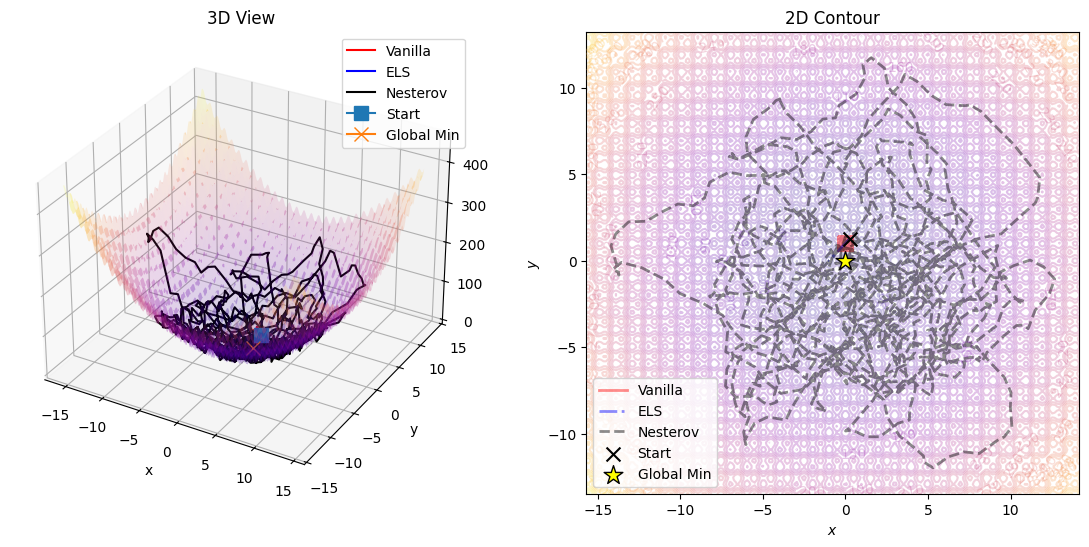

In [22]:
#execute 
its = np.arange(1,1000)
start = [0.25, 1.275]
exact = [0,0]
lr = 0.01
# lr = 0.005
m = 0.75
histV, errV, xv = runA('van',Rastrigin, gradientRastrigin, start, exact, its, lr,m)
histEl, errEl, xE = runA('EL',Rastrigin, gradientRastrigin, start, exact, its, lr,m)
histNest, errN, xN = runA('nest', Rastrigin, gradientRastrigin, start, exact, its, lr,m)

# find the best way to make the image
allPts = np.vstack([histV, histEl, histNest])

x_min = allPts[:,0].min()-1.5
x_max = allPts[:,0].max()+1.5
y_min = allPts[:,1].min()-1.5
y_max = allPts[:,1].max()+1.5
xRange = np.linspace(x_min, x_max, 200)
yRange = np.linspace(y_min,y_max,200)
X, Y = np.meshgrid(xRange,yRange)
Z = Rastrigin(X, Y)

fig = plt.figure(figsize=(14,6))
paths = [
    (histV, xv, 'red','-', 'Vanilla'),
    (histEl, xE, 'blue','-.', 'ELS'),
    (histNest,xN, 'black','--', 'Nesterov')
]
ax1 =fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='plasma', linewidth=0, alpha = 0.15)

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=50, cmap='plasma', alpha = 0.25)


for path, end, co,lstyle, label in paths:
    path = np.array(path)
    ax1.plot(path[:,0], path[:,1], Rastrigin(path[:,0], path[:,1]), color=co, label=label)
    #ax1.plot(end[0], end[1], Rastrigin(end[0], end[1]), color=c, marker='*')
    ax2.plot(path[:,0], path[:,1], color=co, linestyle=lstyle, label=label, alpha = 0.45, linewidth=2)
    # ax2.annotate(f'{label} end', xy=(end[0], end[1]), xycoords='data')
ax1.plot(start[0], start[1], Rastrigin(start[0], start[1]), marker='s', markersize=10, label="Start")
ax1.legend()

plt.clabel(contour, inline=True)

ax1.plot(exact[0], exact[1], Rastrigin(exact[0], exact[1]), marker='x',markersize=10, label='Global Min')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
# ax1.view_init(elev=35, azim=140);
ax1.set_title("3D View")
ax2.scatter(start[0], start[1], color='black', marker='x', s=100, label='Start', zorder=5)
ax2.scatter(exact[0], exact[1], color='yellow', marker='*', s=200, label='Global Min', edgecolors='black', zorder=5)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_title("2D Contour")
ax2.legend()
ax2.set_xlabel(f"$x$")
ax2.set_ylabel(f"$y$")
ax1.legend()
plt.show();

#### Summary:

Vanilla and ELS look like they're winning however thats just because they dive straight into the nearest pit. They are both stuck in local minima. Nesterov Gradient Descent is overshooting those local minimia and thus not getting stuck and its using the momentum to roll itself towards the Global Minimum. 

## Stochastic Gradient Descent

In Stochastic Gradient Descent, our goal is to fit a function to match with some input and output data. To optimize, we can rephrase the gradient descent problem of minimizing the error of a function over this data. This means the variables we optimize correspond to coefficients of a function. Our goal is to find the best coefficients of our test function that minimizes the data.

In the cells below we explore applying Stochastic Gradient Descent (SGD) to the curve fitting problem. To do this, we define a single-layer neural network which is effectively a linear combination of an activation function. Additionally, we define two different optimizers to solve this problem, SGD and Adam. 

In [33]:
def generate_NN_functions(act_fn, act_fn_dif_a, act_fn_dif_b, neurons=3):
    # Method to evaluate the NN given x
    def NN(x, w):
        s = 0

        # Add linear combination of activation functions
        for i in range(neurons):
            s += w[i*3+2] * act_fn(w[i*3]*x + w[i*3+1])
        
        # Add bias term
        s += w[-1]

        return s

    # Generate MSE loss for the NN
    def loss(x, y, w):
        return ((y - NN(x, w))**2).sum()
    
    # Compute gradient of the loss function with respect to NN's weights
    def grad(x, y, w):
        if isinstance(x, np.ndarray):
            g = np.zeros((w.shape[0], x.shape[0]))
        else:
            g = np.zeros_like(w)
        
        for i in range(neurons):
            # Partial derivatives with respect to a_i
            g[i*3] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_a(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to b_i
            g[i*3+1] = -2 * (y - NN(x, w)) * w[i*3+2] * act_fn_dif_b(w[i*3], w[i*3+1], x)

            # Partial derivatives with respect to c_i
            g[i*3+2] = -2 * (y - NN(x, w)) * act_fn(w[i*3]*x + w[i*3+1])

        # Final partial derivative - with respect to bias term
        g[-1] = -2 * (y - NN(x, w))

        return g
    
    # Return the methods with respect to the neural network
    return NN, loss, grad

In [34]:
class SGD_Optimizer:
    def __init__(self, lr, alpha=0.01, lr_decay=0.001):
        """
        Implements basic stochastic gradient descent with momentum. 
        
        Params:
            - lr: The learning rate. Common values are around 0.01 & 0.001
            - alpha: Momentum constant. 0 <= alpha < 1. Higher number means "heavier ball"
            - lr_decay: Rate at which to decay the learning rate. Function of the amount of optimizer steps.
        """
        self.lr = lr
        self.decay = lr_decay
        self.alpha = alpha
        self.last_delta_w = 0
        self.step = 0
    
    def calc_update(self, g):
        """
        Calculates change in weights based on the inputted gradient.
        """
        self.last_delta_w = self.alpha * self.last_delta_w - (self.lr / (1+self.decay*self.step)) * g
        self.step += 1

        return self.last_delta_w

class Adam_Optimizer:
    def __init__(self, lr, beta_1=0.9, beta_2=0.999):
        """
        Implements an Adam-Style gradient descent optimizer.

        Params:
            - lr: The learning rate. Common values are around 0.01 & 0.001
            - beta_1: Mean moment weighting value.
            - beta_2: Variance moment weighting value.
        """
        self.lr = lr
        self.beta_1 = beta_1
        self.beta_2 = beta_2

        self.eps = 1e-8
        self.mean_moment = 0
        self.var_moment = 0

        self.t = 1

    def calc_update(self, g):
        """
        Calculates change in weights based on the inputted gradient.
        """
        self.mean_moment = self.beta_1 * self.mean_moment + (1 - self.beta_1) * g
        self.var_moment = self.beta_2 * self.var_moment + (1 - self.beta_2) * (g**2)

        corrected_mean = self.mean_moment / (1 - self.beta_1**self.t)
        corrected_var = self.var_moment / (1 - self.beta_2**self.t)

        self.t += 1

        return -self.lr * corrected_mean / (np.sqrt(corrected_var) + self.eps)

In [35]:
def optimize(x, y, epochs, batch_size, optimizer, w_start, NN, loss, grad):
    w = w_start.copy()
    l_vect = []

    for i in range(epochs):
        epoch_loss = 0

        # Stores an array of shuffled indices - allows shuffling x & y without changing them
        shuffle = np.arange(len(x))
        np.random.shuffle(shuffle)

        num_batch = len(x) // batch_size
        if len(x) % batch_size != 0:
            num_batch += 1
        
        for b in range(num_batch):
            x_batch = x[shuffle][b*batch_size:(b+1)*batch_size]
            y_batch = y[shuffle][b*batch_size:(b+1)*batch_size]

            # Calculate loss and gradient for this batch
            epoch_loss += 1 / len(x_batch) * loss(x_batch, y_batch, w)
            g = 1 / len(x_batch) * grad(x_batch, y_batch, w).sum(axis=1)

            # Update w based on the optimizer's next step
            w += optimizer.calc_update(g)

        l_vect.append(epoch_loss)
    
    return l_vect, w

In [36]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid (input is a linear transformation) with respect to a
def sig_dif_a(a, b, xi):
    return xi * sig_dif_b(a, b, xi)

# Derivative of sigmoid (input is a linear transformation) with respect to b
def sig_dif_b(a, b, xi):
    return np.exp(-a*xi - b) / ((1 + np.exp(-a*xi - b))**2)

In [37]:
NN, loss, grad = generate_NN_functions(sigmoid, sig_dif_a, sig_dif_b, 4)

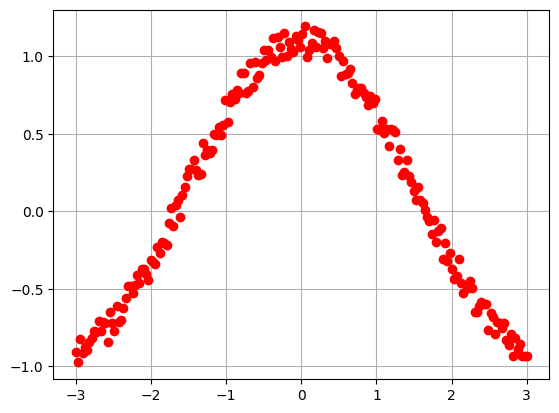

In [38]:
# Data to be trained on - let's have it fit to a noisy curve
np.random.seed(40)

# f = lambda x: np.exp(x) - x**2
f = lambda x: np.cos(x)
noise_scale = 0.2

x = np.linspace(-3, 3, 200)
y = f(x) + np.random.random(x.shape[0]) * noise_scale

plt.plot(x, y, "ro")
plt.grid(True)
plt.show()

In [39]:
w_start = np.random.random(13)

In [40]:
epochs, batch_size = 500, 4

adam = Adam_Optimizer(0.001)
sgd = SGD_Optimizer(0.001, 0.9, lr_decay=0.01)

adam_l_vect, adam_w = optimize(x, y, epochs, batch_size, adam, w_start, NN, loss, grad)
sgd_l_vect, sgd_w = optimize(x, y, epochs, batch_size, sgd, w_start, NN, loss, grad)

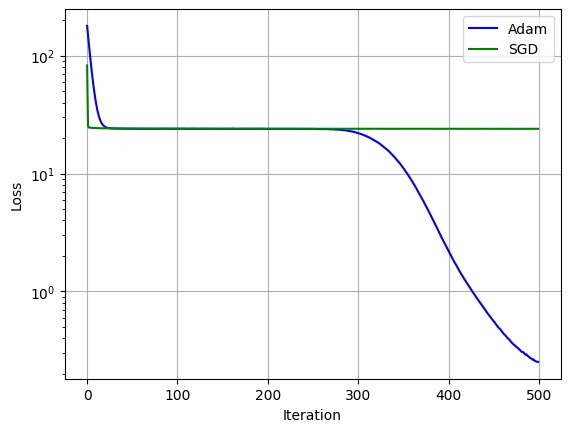

In [41]:
plt.semilogy(adam_l_vect, "b", sgd_l_vect, "g")
plt.legend(["Adam", "SGD"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True);

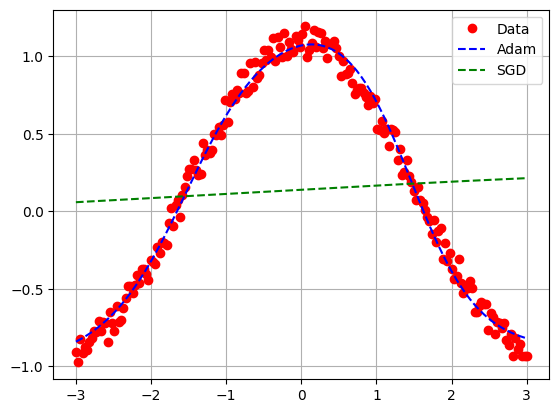

In [43]:
plt.plot(x, y, "ro", x, NN(x, adam_w), "--b", x, NN(x, sgd_w), "--g")
plt.legend(["Data", "Adam", "SGD"])
plt.grid(True)

In [42]:
# Now let's try using ReLU as an activation function instead!
def ReLU(x):
    return (x + np.abs(x)) / 2

def ReLU_dif_a(a, b, xi):
    return 1/2 * (xi + xi*(a*xi + b))/np.abs(a*xi + b)

def ReLU_dif_b(a, b, xi):
    return 1/2 * (1 + (a*xi+b)/np.abs(a*xi+b))

In [44]:
NN, loss, grad = generate_NN_functions(ReLU, ReLU_dif_a, ReLU_dif_b, 4)

In [45]:
# Added a couple more neurons so new w_start needs to be defined
w_start = np.random.random(13)

In [46]:
epochs, batch_size = 200, 4

adam = Adam_Optimizer(0.001)
sgd = SGD_Optimizer(0.001, 0.9, lr_decay=0.01)

adam_l_vect, adam_w = optimize(x, y, epochs, batch_size, adam, w_start, NN, loss, grad)
sgd_l_vect, sgd_w = optimize(x, y, epochs, batch_size, sgd, w_start, NN, loss, grad)

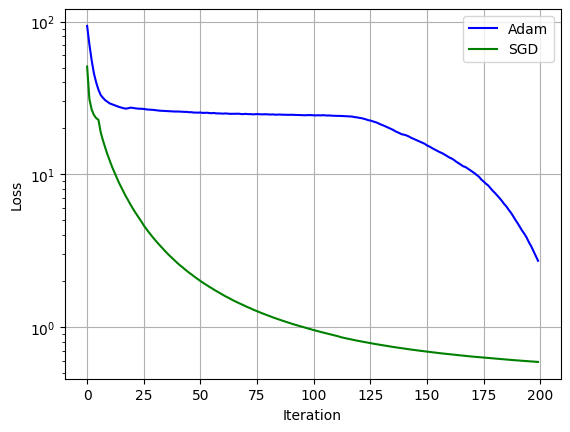

In [47]:
plt.semilogy(adam_l_vect, "b", sgd_l_vect, "g")
plt.legend(["Adam", "SGD"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True);

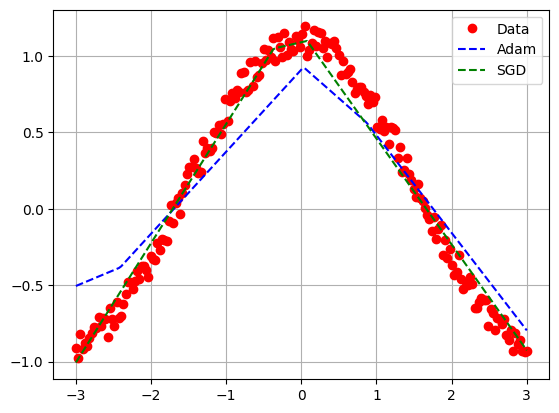

In [48]:
plt.plot(x, y, "ro", x, NN(x, adam_w), "--b", x, NN(x, sgd_w), "--g")
plt.legend(["Data", "Adam", "SGD"])
plt.grid(True)

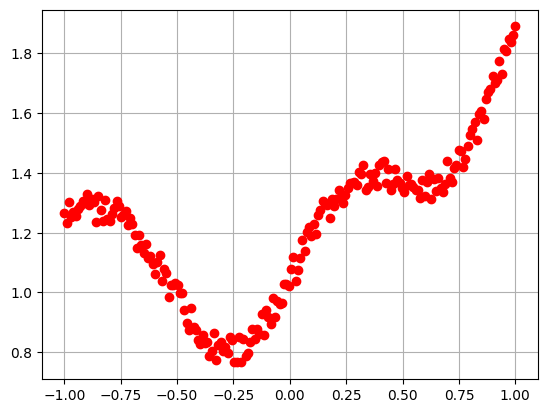

In [49]:
# Let's try a more complicated function to fit to with the optimizers
np.random.seed(40)

f = lambda x: np.exp(x) - x**3 + 1./2 * x * np.cos(5*x)
noise_scale = 0.1

x = np.linspace(-1, 1, 200)
y = f(x) + np.random.random(x.shape[0]) * noise_scale

plt.plot(x, y, "ro")
plt.grid(True)
plt.show()

In [50]:
# Let's fit using a ReLU-powered single layer neural network, with more neurons
n = 15
NN, loss, grad = generate_NN_functions(ReLU, ReLU_dif_a, ReLU_dif_b, n)

w_start = np.random.random(n*3+1)

In [51]:
epochs, batch_size = 500, 8

adam = Adam_Optimizer(0.001)
sgd = SGD_Optimizer(0.001, 0.9, lr_decay=0.01)

adam_l_vect, adam_w = optimize(x, y, epochs, batch_size, adam, w_start, NN, loss, grad)
sgd_l_vect, sgd_w = optimize(x, y, epochs, batch_size, sgd, w_start, NN, loss, grad)

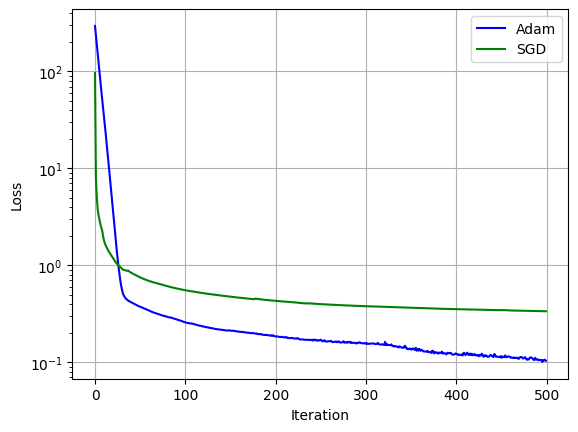

In [52]:
plt.semilogy(adam_l_vect, "b", sgd_l_vect, "g")
plt.legend(["Adam", "SGD"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True);

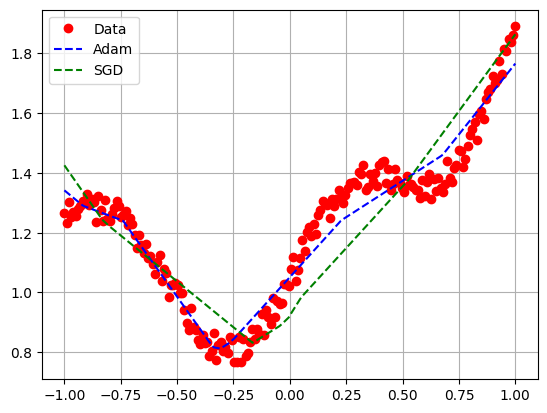

In [53]:
plt.plot(x, y, "ro", x, NN(x, adam_w), "--b", x, NN(x, sgd_w), "--g")
plt.legend(["Data", "Adam", "SGD"])
plt.grid(True)

# Gradient Descent Failures

There are many examples of specific attributes of a function will result in a weak gradient descent; such as ending at a local minimum rather than the global one. Additional issues with the setup of the gradient descent algorithm, such as learning rate sensitivity, can also result in a breakdown. Too large or too small a learning rate can result in unwanted results.

This portion of the notebook explores the failures of the algorithm shown in Python.

## Functions with Multiple Minima

In the cases where there is a function with multiple minima, there exists the possibility of converging at a local minima which is not global. This can be seen in the function immediately below.

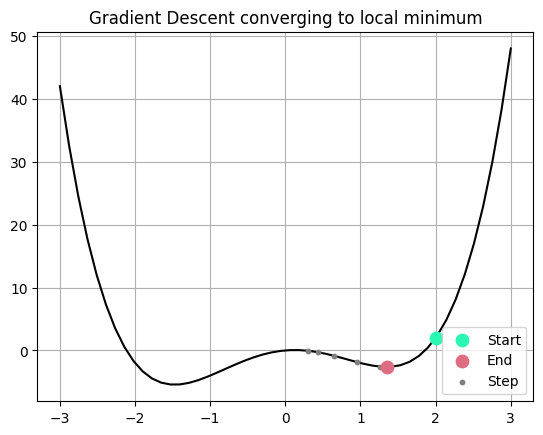

Minimum found at x=1.3470 with f(x)=-2.6186


In [24]:
def f(x):
    return x**4 - 4*x**2 + x
def df(x):
    return 4*x**3 - 8*x + 1

x, path = gradientDescent(start=2)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 50)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to local minimum")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

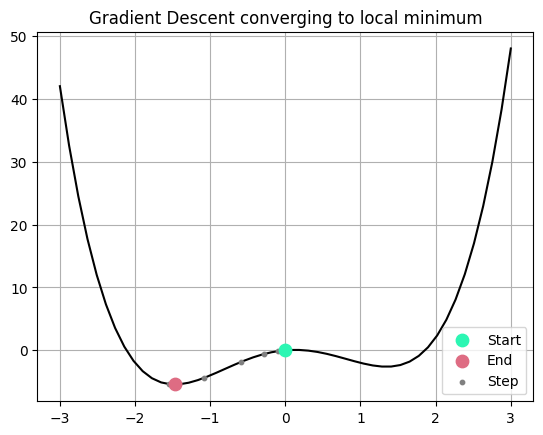

Minimum found at x=-1.4730 with f(x)=-5.4442


In [25]:
x, path = gradientDescent(start=0)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 50)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to local minimum")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

In the first graph it is shown that a poor starting point can result in the incorrect minima; while the first correctly identifies it. With the original unmodified gradient descent, there is no way to necessarily know where to start other than a lucky guess.

## Gradient Descent in Higher Dimensions: Saddle Points

In 3-dimensional and higher planes, there can exist saddle points. Saddle points have a local minimum at the same point as a local maximum.

In [26]:
def TwoDimension_gradientDescent(start=(0.0, 0.0), learningRate=0.1, iterations=100, tol=1e-6):
    x = np.array(start, dtype=float)
    path = [x.copy()]
    for _ in range(iterations):
        step = learningRate * df(x[0], x[1])
        x -= step
        path.append(x.copy())
        if np.linalg.norm(step) < tol:
            break
    return x, np.array(path) 

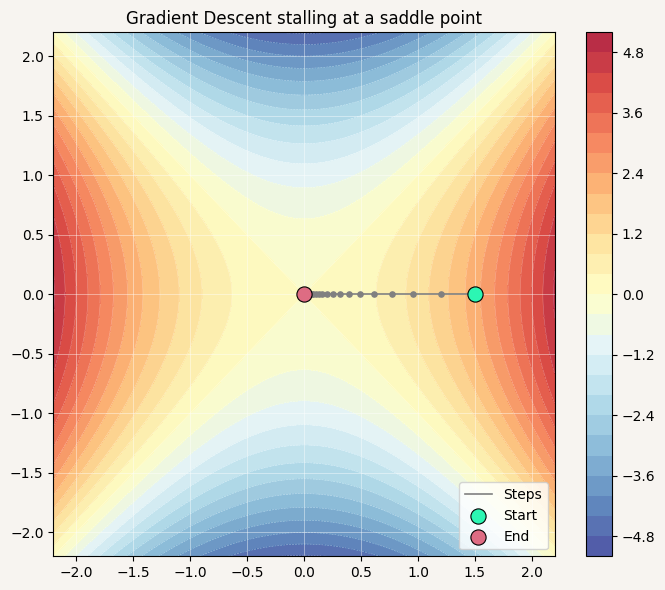

In [27]:
def f(x, y):
    return x**2 - y**2

def df(x, y):
    return np.array([2*x, -2*y])

x, path = TwoDimension_gradientDescent(start=(1.5, 0.0))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#f7f4f0")
ax.set_facecolor("#f7f4f0")

xs = np.linspace(-2.2, 2.2, 400)
ys = np.linspace(-2.2, 2.2, 400)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

cf = ax.contourf(X, Y, Z, levels=30, cmap="RdYlBu_r", alpha=0.85)
ax.contour (X, Y, Z, levels=30, colors="white", linewidths=0.4, alpha=0.5)
fig.colorbar(cf, ax=ax)

ax.plot(path[:, 0], path[:, 1], color="gray", lw=1.2,zorder=4, label="Steps")
ax.scatter(path[:, 0], path[:, 1], c="gray", s=14, zorder=4)
ax.scatter(*path[0],  c="#2CF6B3", s=120, zorder=6, label="Start",edgecolors="black", linewidths=0.8)
ax.scatter(*path[-1], c="#DE6C83", s=120, zorder=6, label="End", edgecolors="black", linewidths=0.8)


ax.legend(loc="lower right")
ax.grid(True, color="white", linewidth=0.5, alpha=0.6)
plt.title("Gradient Descent stalling at a saddle point")

plt.tight_layout()
plt.show()

#### Why does it fail here?
At the ending point, it can be observed dx and dy are equal to zero. Unfortunately, it is not the global minimum. 

It can also be observed gradient descent is not the same as the shortest path to the lowest point. It is only going in the steepest direction.

## Poor Step Sizes

Gradient Descent with a large step size / learning rate can result in some unpredictable results. When using a small step size, we can have a slowly converging functions. With a high step size / learning rate, we can have wildly oscillating results.

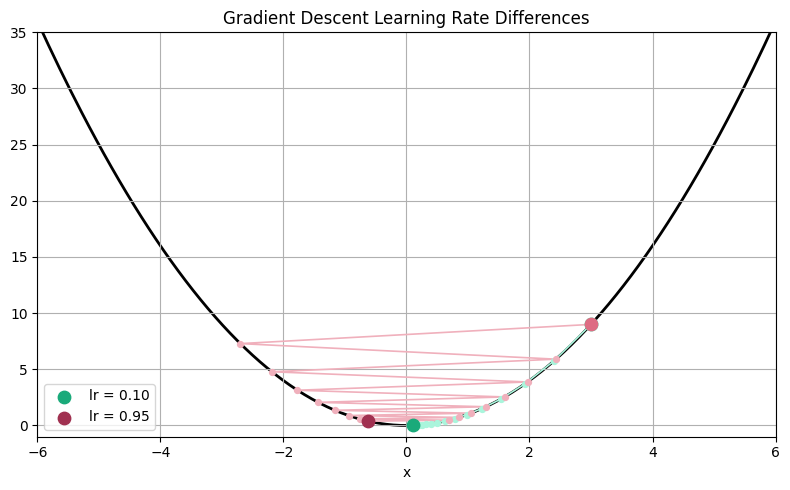

In [32]:
def f(x):
    return x ** 2

def grad_f(x):
    return 2 * x

def gradientDescent(start, lr, n_steps=20):
    path = [start]
    x = start
    for _ in range(n_steps):
        x = x - lr * grad_f(x)
        path.append(x)
        if abs(x) > 1e6:
            break
    return x, path

x0 = 3.0
configs = [
    {"lr": 0.10, "label": "lr = 0.10", "start_color": "#2CF6B3", "end_color": "#1aaa7a", "step_color": "#aaf5dc"},
    # {"lr": 0.90, "label": "lr = 0.90  (oscillates / slow)",  "start_color": "#f5c842", "end_color": "#c49a10", "step_color": "#f5e2a0"},
    {"lr": 0.95, "label": "lr = 0.95",          "start_color": "#DE6C83", "end_color": "#a03050", "step_color": "#f0b0bc"},
]

fig, ax = plt.subplots(figsize=(8, 5))

xs = np.linspace(-6, 6, 200)
ax.plot(xs, f(xs), color="black", linewidth=2, zorder=1)

for cfg in configs:
    _, path = gradientDescent(start=x0, lr=cfg["lr"], n_steps=15)
    path = np.clip(path, -6, 6)
    fpath = np.clip([f(x) for x in path], 0, 50)

    ax.scatter(path[1:-1], fpath[1:-1], c=cfg["step_color"], s=18, zorder=4)
    ax.scatter(path[0],    fpath[0],    c=cfg["start_color"], s=80, zorder=5)
    ax.scatter(path[-1],   fpath[-1],   c=cfg["end_color"],   s=80, zorder=5, label=cfg["label"])
    ax.plot(path, fpath, color=cfg["step_color"], linewidth=1.2, zorder=3)

ax.set_xlim(-6, 6)
ax.set_ylim(-1, 35)
ax.set_xlabel("x")
ax.legend()
ax.grid(True)

plt.title("Gradient Descent Learning Rate Differences")
plt.tight_layout()
plt.show()

## Perturbation

Perturbation allows us to add random noise to the gradient. By doing this, we can have our algorithm do things that seems counter intuitive to gradient descent, like going up a curve rather than exclusively down.
Additionally, we can detect stalling to see if we are at a flatter point. When we see stalling we can give our algorithm a kick to see if it's current spot is the minimum it wants.

In [28]:
def f(x):
    return x**4 - 4*x**2 + x
def df(x):
    return 4*x**3 - 8*x + 1

In [29]:
def gradientDescentPerturb(start=0, learningRate=0.1, iterations=300, tol=1e-6, noise=1.5, stall_window=8, seed=42):
    rng = np.random.default_rng(seed)
    x = float(start)
    path = [x]
    f_history = [f(x)]
    best_x, best_f = x, f(x)

    for i in range(iterations):
        stalled = (len(f_history) >= stall_window and abs(f_history[-1] - f_history[-stall_window]) < tol * 10)

        if stalled:
            x = x + rng.normal(0, noise)
        else:
            step = learningRate * df(x)
            x   -= step
            if abs(step) < tol:
                break

        x  = float(np.clip(x, -4.0, 4.0))
        fx = f(x)
        path.append(x)
        f_history.append(fx)

        if fx < best_f:
            best_f, best_x = fx, x

    return best_x, path

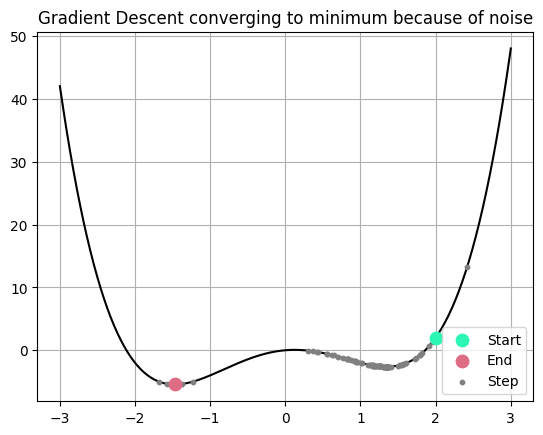

Minimum found at x=-1.4728 with f(x)=-5.4442


In [30]:
x, path = gradientDescentPerturb(start=2, noise=.5)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 400)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to minimum because of noise")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

This new algorithm now is able to find the absolute minimum through perturbation and stall detection.

# Sources

#### Gradient Descent Convergence Theorem Proof
https://www.stat.cmu.edu/~ryantibs/convexopt-F13/scribes/lec6.pdf
https://pages.cs.wisc.edu/~yudongchen/cs726_sp23/Lecture_7_8_other_descent_methods.pdf
https://www.mit.edu/~gfarina/2025/67220s25_L12_gradient_descent/L12.pdf

#### Linear Convergence Proof
https://arxiv.org/pdf/2110.15470

#### Nesterov's Acceleratd Gradient 
https://medium.com/@piyushkashyap045/understanding-nesterov-accelerated-gradient-nag-340c53d64597

- [Back To Top](#Table-of-Contents)